In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tools.eval_measures import rmse
%matplotlib inline

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) 

In [11]:
# dataset source: https://github.com/rouseguy
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')
df.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [12]:
##########################################################################
#################### Visualizando a série temporal ####################### 
##########################################################################

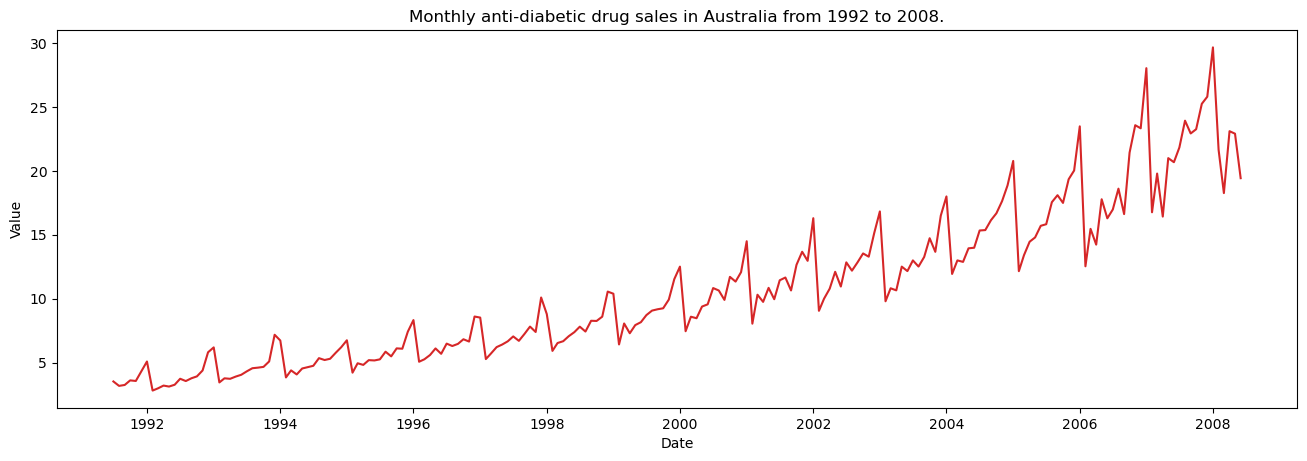

In [13]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df.index, y=df.value, title='Monthly anti-diabetic drug sales in Australia from 1992 to 2008.')    

In [14]:
##########################################################################
##########################################################################
#################### Exponential Smoothing Method ######################## 
##########################################################################
##########################################################################

In [15]:
## Prós e Contras dos Modelos de Suavização Exponencial
## Prós
#  - Pode ser calculado rapidamente
#  - Generaliza bem para muitas séries temporais

## Contras
#  - Ignora a variação aleatória em favor de um processo de suavização
#  - Não pode ser usado para séries de natureza cíclica

In [16]:
##########################################################################
##########################################################################
############## 1. Methods without Trend and seasonality ################## 
##########################################################################
##########################################################################

In [17]:
# ##### Simple Exponential Smoothing
# allow statsmodels to automatically find an optimized α value for ualpha and beta

In [18]:
fit1 = SimpleExpSmoothing(df, initialization_method="estimated").fit()
fcast1 = fit1.forecast(36)

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:132: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  date_key = Timestamp(key, freq=base_index.freq)


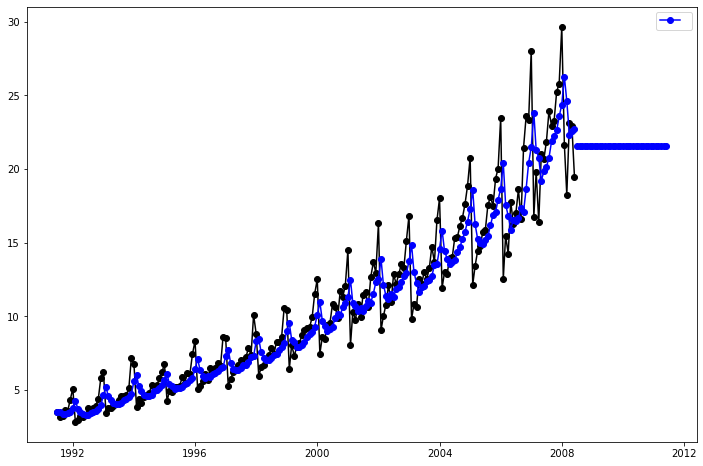

In [19]:
# Plotando o resultado das previsões para cada um dos modelos ajustados
plt.figure(figsize=(12, 8))
plt.plot(df, marker='o', color='black')
plt.plot(fit1.fittedvalues, marker='o', color='blue')
line1, = plt.plot(fcast1, marker='o', color='blue')
plt.legend([line1], [fcast1.name])

In [20]:
##########################################################################
##########################################################################
####################### 2. Methods with Trend ############################ 
##########################################################################
##########################################################################

we allow statsmodels to automatically find optimized value for us. 

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'


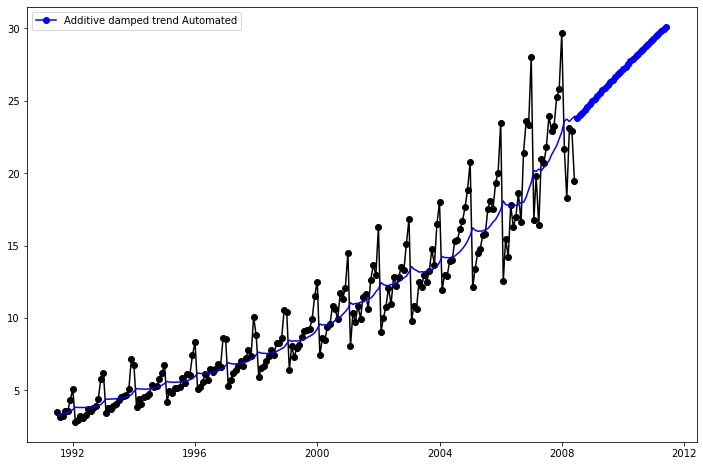

In [21]:
fit1_ht = Holt(df, damped_trend=True, initialization_method="estimated").fit()
fcast1_ht = fit1_ht.forecast(36).rename("Additive damped trend Automated")


plt.figure(figsize=(12, 8))
plt.plot(df, marker='o', color='black')
plt.plot(fit1_ht.fittedvalues, color='blue')
line1, = plt.plot(fcast1_ht, marker='o', color='blue')
plt.legend([line1], [fcast1_ht.name])

We fit five Holt’s models, allow statsmodels to automatically find optimized value for us. 

The below table allows us to compare results when we use exponential versus additive and damped versus non-damped.

Note: fit4 does not allow the parameter ϕ to be optimized by providing a fixed value of ϕ=0.98

In [22]:
fit1 = SimpleExpSmoothing(df, initialization_method="estimated").fit()
fit2 = Holt(df, initialization_method="estimated").fit()
fit3 = Holt(df,exponential=True, initialization_method="estimated").fit()
fit4 = Holt(df,damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fit5 = Holt(df,exponential=True, damped_trend=True, initialization_method="estimated").fit()
params = ['smoothing_level', 'smoothing_trend', 'damping_trend', 'initial_level', 'initial_trend']
results=pd.DataFrame(index=[r"$\alpha$",r"$\beta$",r"$\phi$",r"$l_0$","$b_0$","SSE"] ,columns=['SES', "Holt's","Exponential", "Additive", "Multiplicative"])
results["SES"] =            [fit1.params[p] for p in params] + [fit1.sse]
results["Holt's"] =         [fit2.params[p] for p in params] + [fit2.sse]
results["Exponential"] =    [fit3.params[p] for p in params] + [fit3.sse]
results["Additive"] =       [fit4.params[p] for p in params] + [fit4.sse]
results["Multiplicative"] = [fit5.params[p] for p in params] + [fit5.sse]
results

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\holtwinters\model.py:80: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning:

,SES,Holt's,Exponential,Additive,Multiplicative
$\alpha$,0.359097,0.062609,1.490135e-08,0.086478,0.048836
$\beta$,NaN,0.062609,0.000000e+00,0.086478,0.048836
$\phi$,NaN,NaN,NaN,0.980000,0.995000
$l_0$,3.466521,3.296825,3.607275e+00,3.131403,3.364514
$b_0$,NaN,0.046994,1.009252e+00,0.065611,1.016843
SSE,821.090896,774.587356,7.079206e+02,799.447565,768.155682


C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:132: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  date_key = Timestamp(key, freq=base_index.freq)
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming

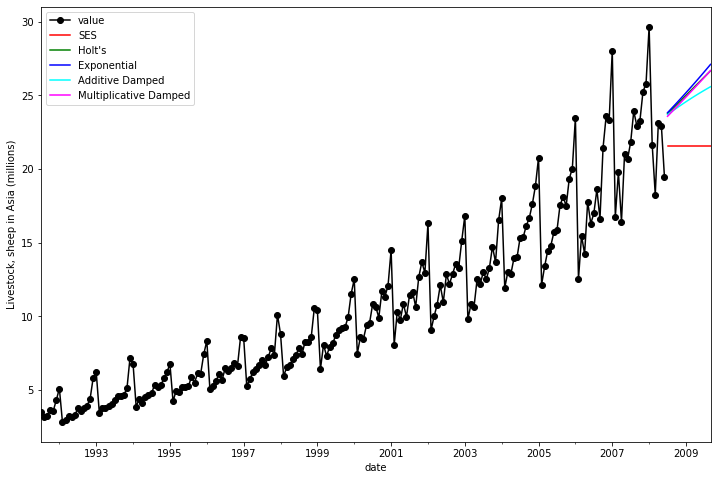

Figure 7.5: Forecasting livestock, sheep in Asia: comparing forecasting performance of non-seasonal methods.


In [23]:
###### Comparison
fit1 = SimpleExpSmoothing(df, initialization_method="estimated").fit()
fcast1 = fit1.forecast(15).rename("SES")
fit2 = Holt(df, initialization_method="estimated").fit()
fcast2 = fit2.forecast(15).rename("Holt's")
fit3 = Holt(df, exponential=True, initialization_method="estimated").fit()
fcast3 = fit3.forecast(15).rename("Exponential")
fit4 = Holt(df, damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fcast4 = fit4.forecast(15).rename("Additive Damped")
fit5 = Holt(df, exponential=True, damped_trend=True, initialization_method="estimated").fit()
fcast5 = fit5.forecast(15).rename("Multiplicative Damped")

ax = df.plot(color="black", marker="o", figsize=(12,8))
fcast1.plot(ax=ax, color='red', legend=True)
fcast2.plot(ax=ax, color='green', legend=True)
fcast3.plot(ax=ax, color='blue', legend=True)
fcast4.plot(ax=ax, color='cyan', legend=True)
fcast5.plot(ax=ax, color='magenta', legend=True)
ax.set_ylabel('Livestock, sheep in Asia (millions)')
plt.show()
print('Figure 7.5: Forecasting livestock, sheep in Asia: comparing forecasting performance of non-seasonal methods.')

In [24]:
##########################################################################
##########################################################################
############### 3. Methods with Trend and seasonality #################### 
##########################################################################
##########################################################################

In [25]:
# Começando com o ajuste de um modelo Holt Winters Aditivo
fit2_htw = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='mul', use_boxcox=True, initialization_method="estimated").fit()
fcast2_htw = fit2_htw.forecast(36).rename("Holt Winters Multiplicativo")
print(fit2_htw.summary())  

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'


                       ExponentialSmoothing Model Results                       
Dep. Variable:                    value   No. Observations:                  204
Model:             ExponentialSmoothing   SSE                            180.945
Optimized:                         True   AIC                              7.535
Trend:                         Additive   BIC                             60.625
Seasonal:                Multiplicative   AICC                            11.233
Seasonal Periods:                    12   Date:                 Sat, 02 May 2026
Box-Cox:                           True   Time:                         16:41:47
Box-Cox Coeff.:                 0.06151                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1284148                alpha                 True
smoothing_trend          

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:132: FutureWarning: The 'freq' argument in Timestamp is deprecated and will be removed in a future version.
  date_key = Timestamp(key, freq=base_index.freq)


In [26]:
y_true = df.values
y_pred = fit2_htw.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.975
MSE:  0.887
RMSE: 0.942
MAE:  0.612
MAPE: 0.802


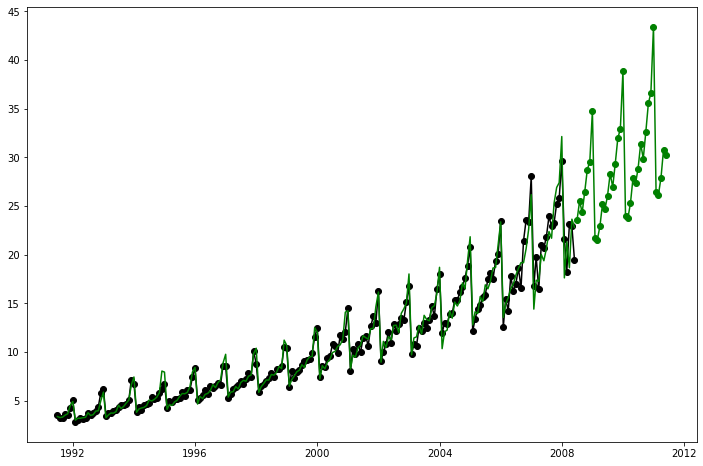

In [27]:
plt.figure(figsize=(12, 8))
plt.plot(df, marker='o', color='black')
plt.plot(fit2_htw.fittedvalues, color='green')
line1, = plt.plot(fcast2_htw, marker='o', color='green')

Finally we are able to run full Holt’s Winters Seasonal Exponential Smoothing including a trend component and a seasonal component. statsmodels allows for all the combinations including as shown in the examples below: <br>1. fit1 additive trend, additive seasonal of period season_length=4 and the use of a Box-Cox transformation. <br>2. fit2 additive trend, multiplicative seasonal of period season_length=4 and the use of a Box-Cox transformation. <br>3. fit3 additive damped trend, additive seasonal of period season_length=4 and the use of a Box-Cox transformation. <br>4. fit4 additive damped trend, multiplicative seasonal of period season_length=4 and the use of a Box-Cox transformation.

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python

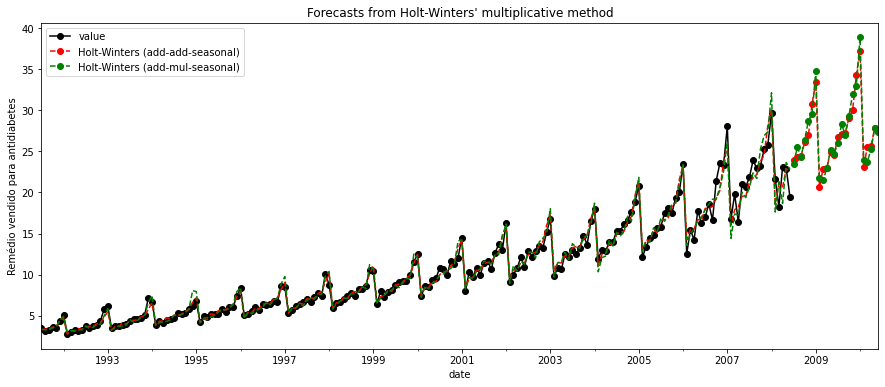

Figure 7.6: Forecasting international visitor nights in Australia using Holt-Winters method with both additive and multiplicative seasonality.


,Additive,Multiplicative,Additive Dam,Multiplica Dam
$\alpha$,1.560140e-01,1.284148e-01,0.183763,0.160820
$\beta$,3.542725e-17,2.129845e-17,0.026478,0.017378
$\phi$,NaN,NaN,0.995000,0.995000
$\gamma$,3.485467e-16,4.735412e-01,0.000000,0.455632
$l_0$,1.230314e+00,1.253224e+00,1.212325,1.243371
$b_0$,1.115597e-02,1.044555e-02,0.014652,0.013044
SSE,1.288756e+02,1.809455e+02,135.264846,185.108580


In [28]:
fit1 = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='add', use_boxcox=True, initialization_method="estimated").fit()
fit2 = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='mul', use_boxcox=True, initialization_method="estimated").fit()
fit3 = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='add', damped_trend=True, use_boxcox=True, initialization_method="estimated").fit()
fit4 = ExponentialSmoothing(df, seasonal_periods=12, trend='add', seasonal='mul', damped_trend=True, use_boxcox=True, initialization_method="estimated").fit()
results=pd.DataFrame(index=[r"$\alpha$",r"$\beta$",r"$\phi$",r"$\gamma$",r"$l_0$","$b_0$","SSE"])
params = ['smoothing_level', 'smoothing_trend', 'damping_trend', 'smoothing_seasonal', 'initial_level', 'initial_trend']
results["Additive"]       = [fit1.params[p] for p in params] + [fit1.sse]
results["Multiplicative"] = [fit2.params[p] for p in params] + [fit2.sse]
results["Additive Dam"]   = [fit3.params[p] for p in params] + [fit3.sse]
results["Multiplica Dam"] = [fit4.params[p] for p in params] + [fit4.sse]

ax = df.plot(figsize=(15,6), marker='o', color='black', title="Forecasts from Holt-Winters' multiplicative method" )
ax.set_ylabel("Remédio vendido para antidiabetes")
ax.set_xlabel("Ano")
fit1.fittedvalues.plot(ax=ax, style='--', color='red')
fit2.fittedvalues.plot(ax=ax, style='--', color='green')

fit1.forecast(24).rename('Holt-Winters (add-add-seasonal)').plot(ax=ax, style='--', marker='o', color='red', legend=True)
fit2.forecast(24).rename('Holt-Winters (add-mul-seasonal)').plot(ax=ax, style='--', marker='o', color='green', legend=True)

# The plot shows the results and forecast for fit1 and fit2. The table allows us to compare the results and parameterizations.
plt.show()
print("Figure 7.6: Forecasting international visitor nights in Australia using Holt-Winters method with both additive and multiplicative seasonality.")

results

Referência: https://www.statsmodels.org/stable/examples/notebooks/generated/exponential_smoothing.html